# Monte Carlo Methods for Reinforcement Learning

## Topics

1. Monte Carlo return and episodic learning  
2. First-Visit Monte Carlo Prediction  
3. Every-Visit Monte Carlo Prediction  
4. First-Visit vs. Every-Visit MC  
5. Monte Carlo Control with Exploring Starts (MC-ES)  
6. Monte Carlo Control with an $\epsilon$-greedy policy  
7. Why Monte Carlo naturally leads to Temporal-Difference learning  

The worked examples intentionally show the episode, the reward after every action, and the backward return calculation

$$
G \leftarrow \gamma G + R_{t+1}.
$$

# 1. Introduction to Monte Carlo Methods

Monte Carlo (MC) methods learn value functions and policies from **sampled experience**. Instead of requiring the full transition model of the environment, the agent generates or receives complete episodes and uses the returns observed in those episodes to estimate values.

For a policy $\pi$, the state-value function is

$$
v_\pi(s)
=
\mathbb{E}_\pi[G_t\mid S_t=s],
$$

and the action-value function is

$$
q_\pi(s,a)
=
\mathbb{E}_\pi[G_t\mid S_t=s,A_t=a].
$$

Monte Carlo methods approximate these expectations by averaging sampled returns.

## What Makes Monte Carlo Learning Different?

Monte Carlo methods have several defining properties.

- **Model-free:** the transition probabilities and expected rewards do not need to be known.
- **Experience-based:** values are estimated directly from sampled episodes.
- **Episodic:** standard Monte Carlo methods require episodes that eventually terminate.
- **Complete-return learning:** the update target is the actual return observed after a state or state-action pair.
- **No bootstrapping:** Monte Carlo does not use an existing estimate such as $V(S_{t+1})$ to construct its target.

The Monte Carlo target is

$$
\boxed{\text{Target}_{MC}=G_t}.
$$

## Monte Carlo vs. Dynamic Programming

Dynamic Programming (DP) and Monte Carlo methods can both evaluate and improve policies, but they obtain their information differently.

| Property | Dynamic Programming | Monte Carlo |
|---|---|---|
| Environment model | Required | Not required |
| Uses sampled experience | Not necessary | Yes |
| Requires complete episodes | No | Yes, for standard MC |
| Bootstrapping | Yes | No |
| Update target | Expected one-step backup | Complete sampled return |
| Main requirement | Known $p(s',r\mid s,a)$ | Sampled episodes |

A typical DP backup is

$$
V_{k+1}^{\pi}(s)
=
\sum_a \pi(a\mid s)
\sum_{s',r}
p(s',r\mid s,a)
\left[
r+\gamma V_k^\pi(s')
\right].
$$

This requires the environment model

$$
p(s',r\mid s,a).
$$

Monte Carlo instead learns from the return observed in an episode:

$$
V(s)
\leftarrow
V(s)
+
\alpha
\left[
G_t-V(s)
\right].
$$

Therefore,

$$
\boxed{\text{Dynamic Programming: model + bootstrapping}}
$$

while

$$
\boxed{\text{Monte Carlo: sampled experience + complete returns}}.
$$

## Model-Free Learning

A method is **model-free** when it can learn without knowing the transition model

$$
p(s',r\mid s,a).
$$

Monte Carlo methods only need experience such as

$$
S_0,A_0,R_1,S_1,A_1,R_2,\ldots,S_T.
$$

From these sampled trajectories, the agent estimates $V(s)$ or $Q(s,a)$ directly.

This is useful when the environment is too complicated to model exactly, but interaction data or recorded episodes are available.

## Episodic Tasks

Standard Monte Carlo methods are most natural for **episodic tasks**.

An episode has a beginning and eventually reaches a terminal state:

$$
S_0,A_0,R_1,S_1,A_1,R_2,\ldots,S_{T-1},A_{T-1},R_T,S_T.
$$

Here,

$$
S_T
$$

is terminal.

Examples include:

- a game that ends with a win, loss, or draw,
- a robot completing a path to a target,
- a Blackjack hand,
- one completed production or service episode.

Because the Monte Carlo return depends on rewards that occur later in the episode, the standard MC update is performed after enough future rewards are known, usually after the episode ends.

## Return from a Complete Episode

The return from time step $t$ is

$$
\boxed{
G_t
=
R_{t+1}
+
\gamma R_{t+2}
+
\gamma^2R_{t+3}
+\cdots
}
$$

For an episode that terminates at time $T$,

$$
\boxed{
G_t
=
\sum_{k=0}^{T-t-1}
\gamma^k R_{t+k+1}
}
$$

where

- $R_{t+1}$ is the next reward,
- $\gamma\in[0,1]$ is the discount factor,
- $T$ is the terminal time.

The same return can be calculated recursively:

$$
\boxed{
G_t
=
R_{t+1}
+
\gamma G_{t+1}
}
$$

or, while processing the stored episode backward,

$$
\boxed{
G
\leftarrow
\gamma G+R_{t+1}
}.
$$


The return is updated using

$$
G \leftarrow \gamma G + R_{t+1}
$$

where:

- $G$: the return accumulated so far while moving backward through the episode.
- $\gamma$: the discount factor, usually $0 \leq \gamma \leq 1$.
- $R_{t+1}$: the reward received immediately after time step $t$.
- $\leftarrow$: means "update" or "replace the old value with the new value."

So the equation can be interpreted as

$$
\boxed{\text{new } G = R_{t+1} + \gamma(\text{old } G)}
$$

## Forward Episode, Backward Return Calculation

The episode itself is generated **forward**:

$$
S_0
\rightarrow
S_1
\rightarrow
S_2
\rightarrow
\cdots
\rightarrow
S_T.
$$

However, after the episode is complete, the return is efficiently calculated **backward**.

Starting with

$$
G=0,
$$

we repeatedly apply

$$
G\leftarrow \gamma G+R_{t+1}.
$$

So keep these two directions separate:

$$
\boxed{\text{Episode generation: forward}}
$$

$$
\boxed{\text{Return calculation: backward}}.
$$

## Online vs. Offline Monte Carlo Learning

The words **online** and **offline** describe how experience becomes available to the learner.

### Online Monte Carlo

In online interaction, the agent continues to generate new experience from the environment.

For each episode:

1. interact with the environment,
2. store the complete episode,
3. calculate its returns,
4. update $V$ or $Q$,
5. generate another episode using the updated information.

Monte Carlo is therefore online **across episodes**, even though the standard MC update normally waits until the current episode has finished.

### Offline Monte Carlo

In offline learning, the agent does not need to interact with the environment while learning. Instead, it learns from a fixed dataset containing previously collected episodes.

For example,

$$
\mathcal D
=
\{E_1,E_2,\ldots,E_N\}.
$$

The learner repeatedly uses the recorded state, action, reward, and next-state information in $\mathcal D$ to estimate value functions or policies.

A useful distinction is

$$
\boxed{\text{Online: new experience continues to be collected}}
$$

$$
\boxed{\text{Offline: learning uses a fixed collected dataset}}.
$$

## On-Policy vs. Off-Policy Monte Carlo

**Online/offline** is different from **on-policy/off-policy**.

### On-Policy

The same policy is used to generate experience and to improve or evaluate itself.

For example, $\epsilon$-greedy Monte Carlo control is typically on-policy:

$$
\boxed{\text{behavior policy}=\text{target policy}=\pi}.
$$

### Off-Policy

One policy generates the data while another policy is evaluated or improved.

- Behavior policy: $b$
- Target policy: $\pi$

Thus,

$$
\boxed{b\neq\pi}.
$$

Off-policy Monte Carlo methods usually correct the difference between the two policies using importance sampling:

$$
\rho_{t:T-1}
=
\prod_{k=t}^{T-1}
\frac{\pi(A_k\mid S_k)}
{b(A_k\mid S_k)}.
$$

The later control sections of this notebook focus mainly on on-policy Monte Carlo methods, including $\epsilon$-greedy control.

# 2. First-Visit Monte Carlo Prediction

First-Visit MC estimates $v_\pi(s)$ by averaging the returns following the **first occurrence** of state $s$ in each episode.

If a state appears several times in one episode, only its earliest occurrence in the original forward episode contributes to the estimate.

For each state,

$$
\text{Returns}(s)=\sum \text{first-visit returns observed for }s,
$$

$$
N(s)=\text{number of first visits used for }s,
$$

and

$$
\boxed{V(s)=\frac{\text{Returns}(s)}{N(s)}}.
$$

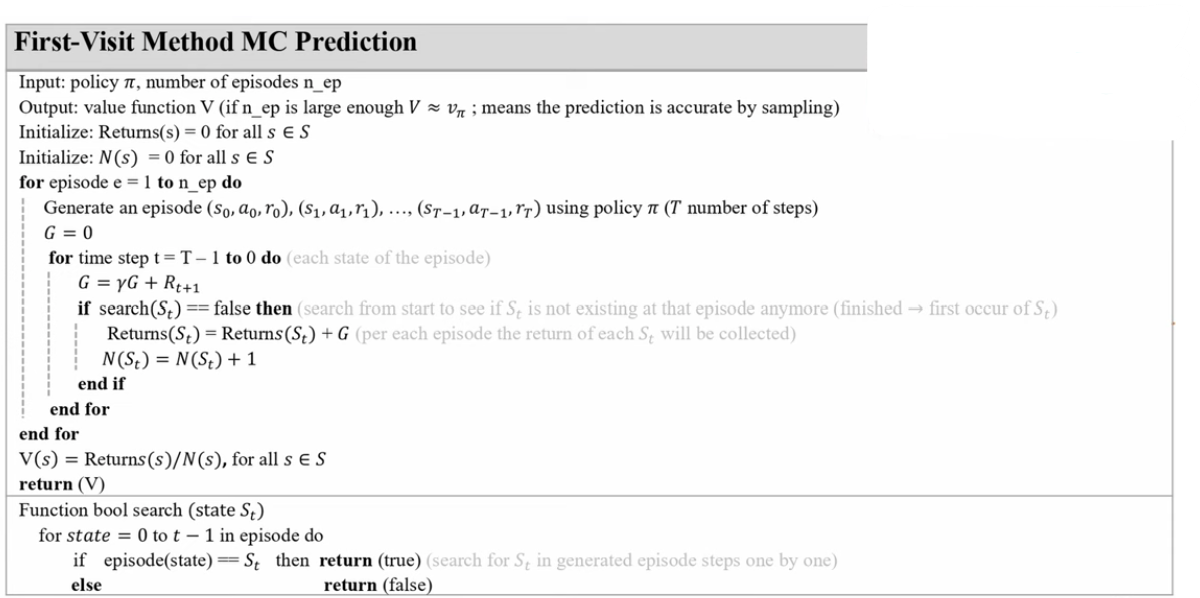

```text
Input: policy π, number of episodes n_ep, discount factor γ

Output: estimated state-value function V

Initialize: V(s) = 0 for all states s
Initialize: Returns(s) = 0 for all states s
Initialize: N(s) = 0 for all states s

For episode = 1 to n_ep:

    1. Generate a complete episode using policy π
       S0, A0, R1, S1, A1, R2, ..., ST

    2. Initialize G = 0

    3. Process the episode backward
       For t = T - 1, T - 2, ..., 0:
           G = γG + R_{t+1}
           If S_t does not appear in S_0, S_1, ..., S_{t-1}:
               Returns(S_t) = Returns(S_t) + G
               N(S_t) = N(S_t) + 1
               V(S_t) = Returns(S_t) / N(S_t)

Return V
```

Although the loop moves backward, **first visit** means the first occurrence of the state in the original forward episode.

## Worked Environment

We use the following $2\times3$ environment.
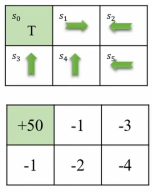

| State | Reward | Policy |
|---|---:|---|
| $s_0$ | $+50$ | Terminal |
| $s_1$ | $-1$ | Right |
| $s_2$ | $-3$ | Left |
| $s_3$ | $-1$ | Up |
| $s_4$ | $-2$ | Up |
| $s_5$ | $-4$ | Left |

For the hand calculations,

$$
\gamma=1.
$$

The reward shown for a transition is the reward received **after taking the action and entering the next state**. A `stop` action contributes reward $0$.

## First-Visit Example Episodes

### Episode $E_1$

Forward episode:

$$
(s_4,U)\rightarrow(s_1,R)\rightarrow(s_2,L)\rightarrow(s_1,\text{stop})
$$

With transition rewards:

$$
\boxed{
(s_4,U,-1)
\rightarrow
(s_1,R,-3)
\rightarrow
(s_2,L,-1)
\rightarrow
(s_1,\text{stop},0)
}
$$

Therefore,

$$
s_4
\xrightarrow{-1}
s_1
\xrightarrow{-3}
s_2
\xrightarrow{-1}
s_1
\xrightarrow{0}
\text{Terminal}.
$$

### Episode $E_1$: backward calculation

Initialize

$$
G=0.
$$

The backward state order is

$$
s_1 \leftarrow s_2 \leftarrow s_1 \leftarrow s_4.
$$

**Step 1: final $s_1$**

$$
G=(1)(0)+0=0.
$$

This is **not** the first visit to $s_1$ in the original episode because $s_1$ already appeared earlier. No update is made.

**Step 2: $s_2$**

$$
G=(1)(0)+(-1)=\boxed{-1}.
$$

$s_2$ has not appeared earlier, so

$$
\text{Returns}(s_2)=0+(-1)=-1,
$$

$$
N(s_2)=1.
$$

**Step 3: first $s_1$**

$$
G=(1)(-1)+(-3)=\boxed{-4}.
$$

This is the first visit to $s_1$, so

$$
\text{Returns}(s_1)=-4,
\qquad
N(s_1)=1.
$$

**Step 4: $s_4$**

$$
G=(1)(-4)+(-1)=\boxed{-5}.
$$

Thus,

$$
\text{Returns}(s_4)=-5,
\qquad
N(s_4)=1.
$$

Episode $E_1$ contributes

$$
\boxed{s_4:-5,\qquad s_1:-4,\qquad s_2:-1}.
$$

### Episode $E_2$

Forward episode:

$$
(s_3,U)\rightarrow(s_0,\text{stop})
$$

With rewards:

$$
s_3\xrightarrow{+50}s_0\xrightarrow{0}\text{Terminal}.
$$

Starting with $G=0$ and moving backward,

$$
G=(1)(0)+50=\boxed{50}.
$$

Therefore,

$$
\boxed{\text{Returns}(s_3)=50,\qquad N(s_3)=1}.
$$

### Episode $E_3$

Forward episode:

$$
(s_5,L)\rightarrow(s_4,U)\rightarrow(s_1,R)\rightarrow(s_2,\text{stop})
$$

With transition rewards:

$$
\boxed{
(s_5,L,-2)
\rightarrow
(s_4,U,-1)
\rightarrow
(s_1,R,-3)
\rightarrow
(s_2,\text{stop},0)
}
$$

Process backward.

For $s_2$,

$$
G=(1)(0)+0=\boxed{0}.
$$

For $s_1$,

$$
G=(1)(0)+(-3)=\boxed{-3}.
$$

For $s_4$,

$$
G=(1)(-3)+(-1)=\boxed{-4}.
$$

For $s_5$,

$$
G=(1)(-4)+(-2)=\boxed{-6}.
$$

Episode $E_3$ contributes

$$
\boxed{s_5:-6,\qquad s_4:-4,\qquad s_1:-3,\qquad s_2:0}.
$$

## Final First-Visit MC Estimates

For $s_1$,

$$
V(s_1)=\frac{-4+(-3)}{2}
=\frac{-7}{2}
=\boxed{-3.5}.
$$

For $s_2$,

$$
V(s_2)=\frac{-1+0}{2}
=\boxed{-0.5}.
$$

For $s_3$,

$$
V(s_3)=\frac{50}{1}
=\boxed{50}.
$$

For $s_4$,

$$
V(s_4)=\frac{-5+(-4)}{2}
=\boxed{-4.5}.
$$

For $s_5$,

$$
V(s_5)=\frac{-6}{1}
=\boxed{-6}.
$$

The estimated value grid is

$$
\boxed{
\begin{array}{|c|c|c|}
\hline
T & -3.5 & -0.5\\
\hline
50 & -4.5 & -6\\
\hline
\end{array}}
$$

In [ ]:
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gamma = 1.0
terminal_states = {"s0"}

episodes_first = {
    "E1": [("s4", "U", -1), ("s1", "R", -3), ("s2", "L", -1), ("s1", "stop", 0)],
    "E2": [("s3", "U", 50), ("s0", "stop", 0)],
    "E3": [("s5", "L", -2), ("s4", "U", -1), ("s1", "R", -3), ("s2", "stop", 0)],
}

def first_visit_mc_prediction(episodes, gamma=1.0, terminal_states=None):
    terminal_states = terminal_states or set()
    returns = defaultdict(list)

    for name, episode in episodes.items():
        G = 0.0
        states = [state for state, _, _ in episode]

        for t in range(len(episode) - 1, -1, -1):
            state, action, reward = episode[t]
            G = gamma * G + reward

            if state in terminal_states:
                continue

            if state not in states[:t]:
                returns[state].append(G)

    values = {state: float(np.mean(gs)) for state, gs in returns.items()}
    return returns, values

first_returns, first_values = first_visit_mc_prediction(episodes_first, gamma, terminal_states)
first_values

{'s2': -0.5, 's1': -3.5, 's4': -4.5, 's3': 50.0, 's5': -6.0}

In [ ]:
first_summary = pd.DataFrame({
    "State": sorted(first_returns),
    "First-Visit Returns": [first_returns[s] for s in sorted(first_returns)],
    "N(s)": [len(first_returns[s]) for s in sorted(first_returns)],
    "Return Sum": [sum(first_returns[s]) for s in sorted(first_returns)],
    "V(s)": [first_values[s] for s in sorted(first_returns)],
})
first_summary

,State,First-Visit Returns,N(s),Return Sum,V(s)
0,s1,"[-4.0, -3.0]",2,-7.0,-3.5
1,s2,"[-1.0, 0.0]",2,-1.0,-0.5
2,s3,[50.0],1,50.0,50.0
3,s4,"[-5.0, -4.0]",2,-9.0,-4.5
4,s5,[-6.0],1,-6.0,-6.0


# 3. Every-Visit Monte Carlo Prediction

Every-Visit MC uses the return following **every occurrence** of a state.

There is no first-visit test.

For every occurrence of $S_t$,

$$
G\leftarrow \gamma G+R_{t+1},
$$

$$
\text{Returns}(S_t)\leftarrow \text{Returns}(S_t)+G,
$$

$$
N(S_t)\leftarrow N(S_t)+1.
$$

Finally,

$$
\boxed{V(s)=\frac{\text{Returns}(s)}{N(s)}}.
$$

## Every-Visit MC Prediction Algorithm

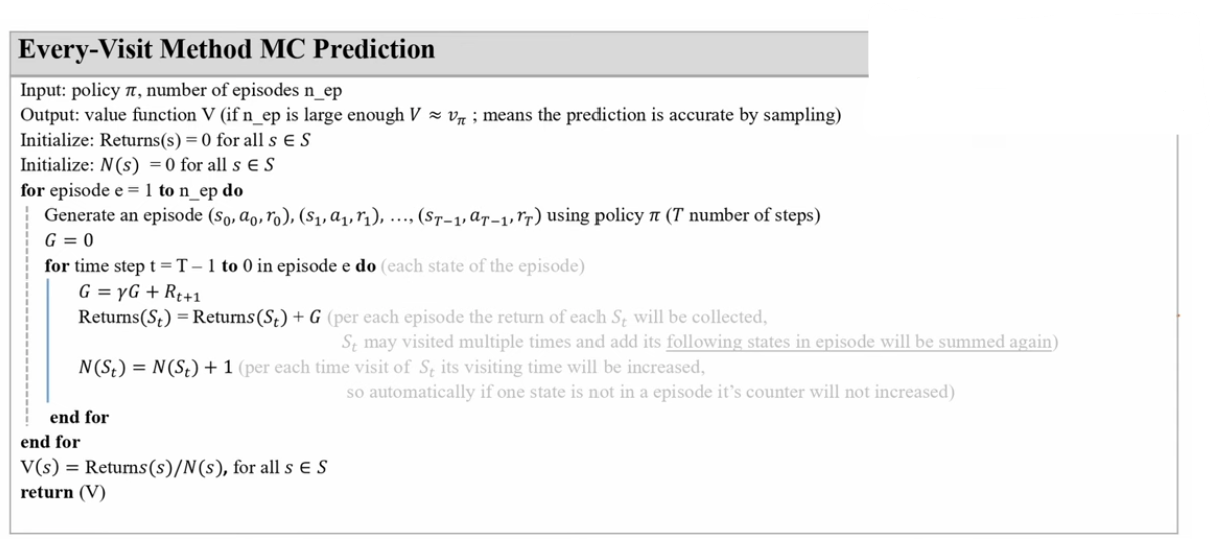

```text
Input:
    policy π
    number of episodes n_ep
    discount factor γ

Output:
    estimated state-value function V

Initialize:
    V(s) = 0 for all states s
    Returns(s) = 0 for all states s
    N(s) = 0 for all states s

For episode = 1 to n_ep:

    1. Generate a complete episode using policy π
       S0, A0, R1, S1, A1, R2, ..., ST

    2. Initialize
       G = 0

    3. Process the episode backward
       For t = T - 1, T - 2, ..., 0:
           G = γG + R_{t+1}
           Returns(S_t) = Returns(S_t) + G
           N(S_t) = N(S_t) + 1
           V(S_t) = Returns(S_t) / N(S_t)

Return V
```

## Every-Visit Example Episodes

The environment and $\gamma=1$ remain the same.

### Episode $E_1$

$$
(s_4,U)
\rightarrow
(s_1,R)
\rightarrow
(s_2,L)
\rightarrow
(s_1,L)
\rightarrow
(s_2,\text{stop})
$$

With rewards:

$$
\boxed{
(s_4,U,-1)
\rightarrow
(s_1,R,-3)
\rightarrow
(s_2,L,-1)
\rightarrow
(s_1,L,-3)
\rightarrow
(s_2,\text{stop},0)
}
$$

The backward order is

$$
s_2\leftarrow s_1\leftarrow s_2\leftarrow s_1\leftarrow s_4.
$$

### Episode $E_1$: every backward step

Initialize

$$
G=0.
$$

**Final $s_2$**

$$
G=(1)(0)+0=\boxed{0}.
$$

Use this visit:

$$
\text{Returns}(s_2)=[0],\qquad N(s_2)=1.
$$

**Second $s_1$**

$$
G=(1)(0)+(-3)=\boxed{-3}.
$$

Use this visit:

$$
\text{Returns}(s_1)=[-3],\qquad N(s_1)=1.
$$

**First $s_2$**

$$
G=(1)(-3)+(-1)=\boxed{-4}.
$$

Use this visit too:

$$
\text{Returns}(s_2)=[0,-4],\qquad N(s_2)=2.
$$

**First $s_1$**

$$
G=(1)(-4)+(-3)=\boxed{-7}.
$$

Again use the visit:

$$
\text{Returns}(s_1)=[-3,-7],\qquad N(s_1)=2.
$$

**$s_4$**

$$
G=(1)(-7)+(-1)=\boxed{-8}.
$$

Thus,

$$
\text{Returns}(s_4)=[-8],\qquad N(s_4)=1.
$$

Episode $E_1$ contributes

$$
\boxed{
s_4:-8,\qquad
s_1:-7,-3,\qquad
s_2:-4,0
}.
$$

### Episode $E_2$

As before,

$$
s_3\xrightarrow{+50}s_0\xrightarrow{0}\text{Terminal}.
$$

Therefore,

$$
\boxed{G(s_3)=50}.
$$

### Episode $E_3$

$$
(s_5,L)
\rightarrow
(s_4,U)
\rightarrow
(s_1,R)
\rightarrow
(s_2,L)
\rightarrow
(s_1,\text{stop})
$$

With rewards:

$$
\boxed{
(s_5,L,-2)
\rightarrow
(s_4,U,-1)
\rightarrow
(s_1,R,-3)
\rightarrow
(s_2,L,-1)
\rightarrow
(s_1,\text{stop},0)
}
$$

Now move backward.

For the final $s_1$,

$$
G=(1)(0)+0=\boxed{0}.
$$

For $s_2$,

$$
G=(1)(0)+(-1)=\boxed{-1}.
$$

For the earlier $s_1$,

$$
G=(1)(-1)+(-3)=\boxed{-4}.
$$

For $s_4$,

$$
G=(1)(-4)+(-1)=\boxed{-5}.
$$

For $s_5$,

$$
G=(1)(-5)+(-2)=\boxed{-7}.
$$

Episode $E_3$ contributes

$$
\boxed{
s_5:-7,\quad
s_4:-5,\quad
s_1:-4,0,\quad
s_2:-1
}.
$$

## Final Every-Visit MC Estimates

For $s_1$, all observed returns are

$$
-7,\,-3,\,-4,\,0.
$$

Therefore,

$$
V(s_1)
=
\frac{-7-3-4+0}{4}
=
\boxed{-3.5}.
$$

For $s_2$,

$$
V(s_2)
=
\frac{-4+0-1}{3}
=
-\frac{5}{3}
\approx
\boxed{-1.67}.
$$

For $s_3$,

$$
V(s_3)=\boxed{50}.
$$

For $s_4$,

$$
V(s_4)
=
\frac{-8-5}{2}
=
\boxed{-6.5}.
$$

For $s_5$,

$$
V(s_5)=\boxed{-7}.
$$

The estimated value grid is

$$
\boxed{
\begin{array}{|c|c|c|}
\hline
T & -3.5 & -1.67\\
\hline
50 & -6.5 & -7\\
\hline
\end{array}}
$$

In [ ]:
episodes_every = {
    "E1": [("s4", "U", -1), ("s1", "R", -3), ("s2", "L", -1), ("s1", "L", -3), ("s2", "stop", 0)],
    "E2": [("s3", "U", 50), ("s0", "stop", 0)],
    "E3": [("s5", "L", -2), ("s4", "U", -1), ("s1", "R", -3), ("s2", "L", -1), ("s1", "stop", 0)],
}

def every_visit_mc_prediction(episodes, gamma=1.0, terminal_states=None):
    terminal_states = terminal_states or set()
    returns = defaultdict(list)

    for name, episode in episodes.items():
        G = 0.0

        for t in range(len(episode) - 1, -1, -1):
            state, action, reward = episode[t]
            G = gamma * G + reward

            if state in terminal_states:
                continue

            returns[state].append(G)

    values = {state: float(np.mean(gs)) for state, gs in returns.items()}
    return returns, values

every_returns, every_values = every_visit_mc_prediction(episodes_every, gamma, terminal_states)
every_values

{'s2': -1.6666666666666667, 's1': -3.5, 's4': -6.5, 's3': 50.0, 's5': -7.0}

In [ ]:
every_summary = pd.DataFrame({
    "State": sorted(every_returns),
    "Every-Visit Returns": [sorted(every_returns[s]) for s in sorted(every_returns)],
    "N(s)": [len(every_returns[s]) for s in sorted(every_returns)],
    "Return Sum": [sum(every_returns[s]) for s in sorted(every_returns)],
    "V(s)": [every_values[s] for s in sorted(every_returns)],
})
every_summary

,State,Every-Visit Returns,N(s),Return Sum,V(s)
0,s1,"[-7.0, -4.0, -3.0, 0.0]",4,-14.0,-3.500000
1,s2,"[-4.0, -1.0, 0.0]",3,-5.0,-1.666667
2,s3,[50.0],1,50.0,50.000000
3,s4,"[-8.0, -5.0]",2,-13.0,-6.500000
4,s5,[-7.0],1,-7.0,-7.000000


# 4. First-Visit vs. Every-Visit MC

The difference is entirely in **which occurrences contribute to the average**.

| Method | Repeated state inside one episode |
|---|---|
| First-Visit MC | Use only the earliest occurrence |
| Every-Visit MC | Use every occurrence |

Both methods calculate returns with the same backward recursion:

$$
G\leftarrow \gamma G+R_{t+1}.
$$

For the worked examples, repeated visits change the estimates for $s_2$, $s_4$, and $s_5$ because the Every-Visit example contains additional repeated-state trajectories.

In [ ]:
comparison = pd.DataFrame({
    "State": ["s1", "s2", "s3", "s4", "s5"],
    "First-Visit V(s)": [first_values[s] for s in ["s1", "s2", "s3", "s4", "s5"]],
    "Every-Visit V(s)": [every_values[s] for s in ["s1", "s2", "s3", "s4", "s5"]],
})
comparison

,State,First-Visit V(s),Every-Visit V(s)
0,s1,-3.5,-3.500000
1,s2,-0.5,-1.666667
2,s3,50.0,50.000000
3,s4,-4.5,-6.500000
4,s5,-6.0,-7.000000


# 5. Monte Carlo Control with Exploring Starts

Prediction estimates the value of a **given** policy. Control tries to improve the policy and approach an optimal policy.

For model-free control, action values are needed:

$$
q_\pi(s,a)
=
\mathbb{E}_\pi[G_t\mid S_t=s,A_t=a].
$$

Monte Carlo Exploring Starts (MC-ES) estimates

$$
Q(s,a)
$$

and repeatedly makes the policy greedy with respect to the current action-value estimates:

$$
\boxed{
\pi(s)=\arg\max_a Q(s,a)
}.
$$

The exploring-start assumption requires every valid state-action pair to have a nonzero probability of being selected as the starting pair.

## MC Exploring Starts Algorithm
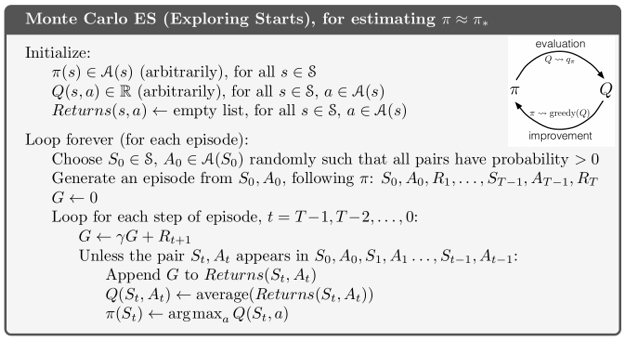

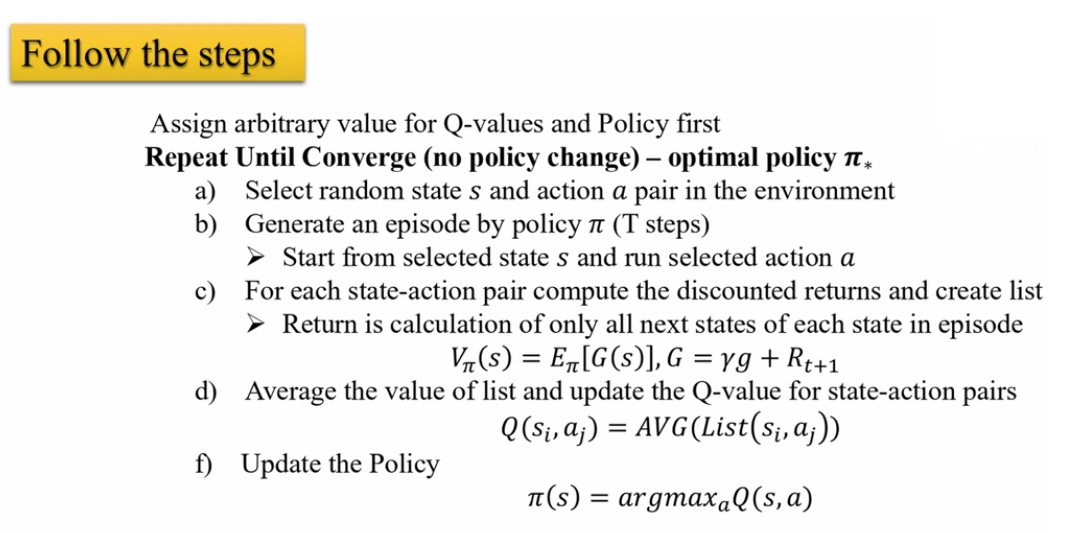

```text
Input:
    discount factor γ

Initialize:
    π(s) arbitrarily for every state s
    Q(s, a) arbitrarily for every valid pair (s, a)
    Returns(s, a) as an empty list

Repeat for each episode:

    1. Choose an exploring start
       Select S0 and A0 randomly so that every valid pair has probability > 0

    2. Generate an episode
       Execute A0 from S0
       Then follow the current policy π
       S0, A0, R1, ..., S_{T-1}, A_{T-1}, R_T

    3. Initialize
       G = 0

    4. Process the episode backward
       For t = T - 1, T - 2, ..., 0:

           G = γG + R_{t+1}

           If (S_t, A_t) does not appear earlier in the same episode:

               Append G to Returns(S_t, A_t)

               Q(S_t, A_t) = average(Returns(S_t, A_t))

               π(S_t) = argmax_a Q(S_t, a)

Repeat until the policy stabilizes or the
chosen training budget is reached.
```

The first-visit check is now performed on the **state-action pair** $(S_t,A_t)$, not only on the state.

## MC-ES Path-Planning Environment

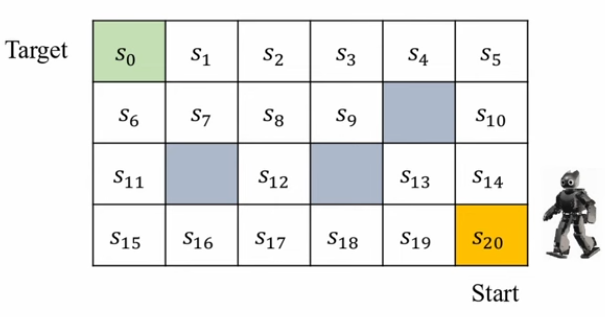

A robot moves in a $4\times6$ grid.

- Target: $s_0$
- Example start location shown in the environment: $s_{20}$
- Reward for entering $s_0$: $+100$
- Reward for every other transition: $-1$
- Discount factor:

$$
\gamma=0.9.
$$

Blocked cells are not valid states.

For the hand-worked MC-ES example, the initial policy is arbitrary. To avoid making an unvisited action with value $0$ look better than a sampled action with a negative return, the Python verification below initializes unvisited $Q(s,a)$ values to a very low arbitrary number. This keeps the example consistent with the greedy policy updates shown in the worked episodes.

Episode $E_1$ is treated as a finite-horizon sampled episode: after the final executed action, the continuation return is initialized with $G=0$.

In [ ]:
grid = [
    ["s0", "s1", "s2", "s3", "s4", "s5"],
    ["s6", "s7", "s8", "s9", None, "s10"],
    ["s11", None, "s12", None, "s13", "s14"],
    ["s15", "s16", "s17", "s18", "s19", "s20"],
]

positions = {}
for r, row in enumerate(grid):
    for c, state in enumerate(row):
        if state is not None:
            positions[state] = (r, c)

action_delta = {"U": (-1, 0), "D": (1, 0), "L": (0, -1), "R": (0, 1)}

def valid_actions(state):
    r, c = positions[state]
    valid = []
    for action, (dr, dc) in action_delta.items():
        nr, nc = r + dr, c + dc
        if 0 <= nr < len(grid) and 0 <= nc < len(grid[0]) and grid[nr][nc] is not None:
            valid.append(action)
    return valid

initial_policy = {
    "s1": "L", "s2": "L", "s3": "L", "s4": "R", "s5": "L",
    "s6": "R", "s7": "R", "s8": "D", "s9": "U", "s10": "U",
    "s11": "U", "s12": "D", "s13": "R", "s14": "U",
    "s15": "U", "s16": "L", "s17": "L", "s18": "R",
    "s19": "L", "s20": "L",
}

policy_table = pd.DataFrame(grid).replace(initial_policy)
policy_table

,0,1,2,3,4,5
0,s0,L,L,L,R,L
1,R,R,D,U,None,U
2,U,None,D,None,R,U
3,U,L,L,R,L,L


## Episode $E_1$

Exploring start:

$$
\boxed{(s_7,L)}.
$$

Generated episode:

$$
(s_7,L)
\rightarrow
(s_6,R)
\rightarrow
(s_7,R)
\rightarrow
(s_8,D)
\rightarrow
(s_{12},D)
\rightarrow
(s_{17},L)
\rightarrow s_{16}.
$$

Every executed transition has reward $-1$:

$$
\boxed{
(s_7,L,-1)
\rightarrow
(s_6,R,-1)
\rightarrow
(s_7,R,-1)
\rightarrow
(s_8,D,-1)
\rightarrow
(s_{12},D,-1)
\rightarrow
(s_{17},L,-1)
}.
$$

Now calculate backward from $G=0$.

For $(s_{17},L)$,

$$
G=(0.9)(0)-1=\boxed{-1}.
$$

For $(s_{12},D)$,

$$
G=(0.9)(-1)-1=\boxed{-1.9}.
$$

For $(s_8,D)$,

$$
G=(0.9)(-1.9)-1=\boxed{-2.71}.
$$

For $(s_7,R)$,

$$
G=(0.9)(-2.71)-1=\boxed{-3.439}.
$$

For $(s_6,R)$,

$$
G=(0.9)(-3.439)-1=\boxed{-4.0951}.
$$

For the exploring-start pair $(s_7,L)$,

$$
G=(0.9)(-4.0951)-1
=
\boxed{-4.68559}.
$$

### $Q$ update after $E_1$

The first return list for each observed pair contains one value, so the average equals that value:

$$
Q(s_{17},L)=-1,
$$

$$
Q(s_{12},D)=-1.9,
$$

$$
Q(s_8,D)=-2.71,
$$

$$
Q(s_7,R)=-3.439,
$$

$$
Q(s_6,R)=-4.0951,
$$

$$
Q(s_7,L)=-4.68559.
$$

At $s_7$, compare the sampled actions:

$$
Q(s_7,R)=-3.439,
$$

$$
Q(s_7,L)=-4.68559.
$$

Since

$$
-3.439>-4.68559,
$$

the greedy update gives

$$
\boxed{\pi(s_7)=R}.
$$

## Episode $E_2$

Exploring start:

$$
\boxed{(s_8,R)}.
$$

Generated episode:

$$
(s_8,R)
\rightarrow
(s_9,U)
\rightarrow
(s_3,L)
\rightarrow
(s_2,L)
\rightarrow
(s_1,L)
\rightarrow s_0.
$$

With rewards:

$$
\boxed{
(s_8,R,-1)
\rightarrow
(s_9,U,-1)
\rightarrow
(s_3,L,-1)
\rightarrow
(s_2,L,-1)
\rightarrow
(s_1,L,+100)
}.
$$

Start from $G=0$ and move backward:

$$
(s_1,L):
\quad
G=(0.9)(0)+100
=
\boxed{100},
$$

$$
(s_2,L):
\quad
G=(0.9)(100)-1
=
\boxed{89},
$$

$$
(s_3,L):
\quad
G=(0.9)(89)-1
=
\boxed{79.1},
$$

$$
(s_9,U):
\quad
G=(0.9)(79.1)-1
=
\boxed{70.19},
$$

$$
(s_8,R):
\quad
G=(0.9)(70.19)-1
=
\boxed{62.171}.
$$

### Policy update after $E_2$

At $s_8$,

$$
Q(s_8,D)=-2.71
$$

from $E_1$, while

$$
Q(s_8,R)=62.171
$$

from $E_2$.

Therefore,

$$
\boxed{\pi(s_8)=R}.
$$

## Episode $E_3$

Exploring start:

$$
\boxed{(s_{12},U)}.
$$

Generated episode:

$$
(s_{12},U)
\rightarrow
(s_8,R)
\rightarrow
(s_9,U)
\rightarrow
(s_3,L)
\rightarrow
(s_2,L)
\rightarrow
(s_1,L)
\rightarrow s_0.
$$

With rewards:

$$
\boxed{
(s_{12},U,-1)
\rightarrow
(s_8,R,-1)
\rightarrow
(s_9,U,-1)
\rightarrow
(s_3,L,-1)
\rightarrow
(s_2,L,-1)
\rightarrow
(s_1,L,+100)
}.
$$

Moving backward:

$$
(s_1,L):\quad G=(0.9)(0)+100=\boxed{100},
$$

$$
(s_2,L):\quad G=(0.9)(100)-1=\boxed{89},
$$

$$
(s_3,L):\quad G=(0.9)(89)-1=\boxed{79.1},
$$

$$
(s_9,U):\quad G=(0.9)(79.1)-1=\boxed{70.19},
$$

$$
(s_8,R):\quad G=(0.9)(70.19)-1=\boxed{62.171},
$$

$$
(s_{12},U):\quad G=(0.9)(62.171)-1=\boxed{54.9539}.
$$

Because several pairs were also visited in $E_2$,

$$
\text{Returns}(s_8,R)=[62.171,62.171],
$$

so

$$
Q(s_8,R)
=
\frac{62.171+62.171}{2}
=
62.171.
$$

At $s_{12}$,

$$
Q(s_{12},D)=-1.9,
$$

$$
Q(s_{12},U)=54.9539.
$$

Therefore,

$$
\boxed{\pi(s_{12})=U}.
$$

## Episode $E_4$

Exploring start:

$$
\boxed{(s_7,U)}.
$$

Generated episode:

$$
(s_7,U)\rightarrow(s_1,L)\rightarrow s_0.
$$

With rewards:

$$
\boxed{
(s_7,U,-1)
\rightarrow
(s_1,L,+100)
}.
$$

Move backward.

For $(s_1,L)$,

$$
G=(0.9)(0)+100=\boxed{100}.
$$

For $(s_7,U)$,

$$
G=(0.9)(100)-1=\boxed{89}.
$$

The return list for $(s_1,L)$ is now

$$
[100,100,100],
$$

so

$$
Q(s_1,L)=100.
$$

For $s_7$,

$$
Q(s_7,L)=-4.68559,
$$

$$
Q(s_7,R)=-3.439,
$$

$$
Q(s_7,U)=89.
$$

Therefore,

$$
\boxed{\pi(s_7)=U}.
$$

In [ ]:
mc_es_episodes = {
    "E1": [("s7", "L", -1), ("s6", "R", -1), ("s7", "R", -1), ("s8", "D", -1), ("s12", "D", -1), ("s17", "L", -1)],
    "E2": [("s8", "R", -1), ("s9", "U", -1), ("s3", "L", -1), ("s2", "L", -1), ("s1", "L", 100)],
    "E3": [("s12", "U", -1), ("s8", "R", -1), ("s9", "U", -1), ("s3", "L", -1), ("s2", "L", -1), ("s1", "L", 100)],
    "E4": [("s7", "U", -1), ("s1", "L", 100)],
}

def initialize_q(low_value=-1e9):
    Q = {}
    for state in positions:
        if state == "s0":
            continue
        for action in valid_actions(state):
            Q[(state, action)] = low_value
    return Q

def greedy_action_from_q(state, Q):
    actions = valid_actions(state)
    best_value = max(Q[(state, action)] for action in actions)
    return sorted([action for action in actions if Q[(state, action)] == best_value])[0]

def mc_es_update(episode, returns, Q, policy, gamma=0.9):
    G = 0.0
    pairs = [(state, action) for state, action, _ in episode]
    detail = []

    for t in range(len(episode) - 1, -1, -1):
        state, action, reward = episode[t]
        G = gamma * G + reward
        pair = (state, action)
        first_visit = pair not in pairs[:t]

        if first_visit:
            returns[pair].append(G)
            Q[pair] = float(np.mean(returns[pair]))
            policy[state] = greedy_action_from_q(state, Q)

        detail.append((t, state, action, reward, G, first_visit))

    return list(reversed(detail))

returns_es = defaultdict(list)
Q_es = initialize_q()
policy_es = initial_policy.copy()

episode_details = {}
for name, episode in mc_es_episodes.items():
    episode_details[name] = mc_es_update(episode, returns_es, Q_es, policy_es, gamma=0.9)

observed_q = pd.DataFrame(
    [(s, a, returns_es[(s, a)], Q_es[(s, a)]) for s, a in sorted(returns_es)],
    columns=["State", "Action", "Returns List", "Q(s,a)"]
)
observed_q

,State,Action,Returns List,"Q(s,a)"
0,s1,L,"[100.0, 100.0, 100.0]",100.00000
1,s12,D,[-1.9],-1.90000
2,s12,U,[54.95390000000001],54.95390
3,s17,L,[-1.0],-1.00000
4,s2,L,"[89.0, 89.0]",89.00000
5,s3,L,"[79.10000000000001, 79.10000000000001]",79.10000
6,s6,R,[-4.0951],-4.09510
7,s7,L,[-4.68559],-4.68559
8,s7,R,[-3.439],-3.43900
9,s7,U,[89.0],89.00000


In [ ]:
for name in ["E1", "E2", "E3", "E4"]:
    print(f"\n{name} backward-return details")
    display(pd.DataFrame(
        episode_details[name],
        columns=["t", "State", "Action", "Reward", "G", "First visit of (s,a)?"]
    ))

print("Selected policy states after E4:")
display(pd.DataFrame({
    "State": ["s7", "s8", "s12"],
    "Initial Policy": [initial_policy[s] for s in ["s7", "s8", "s12"]],
    "Updated Policy": [policy_es[s] for s in ["s7", "s8", "s12"]],
}))


E1 backward-return details


,t,State,Action,Reward,G,"First visit of (s,a)?"
0,0,s7,L,-1,-4.68559,True
1,1,s6,R,-1,-4.09510,True
2,2,s7,R,-1,-3.43900,True
3,3,s8,D,-1,-2.71000,True
4,4,s12,D,-1,-1.90000,True
5,5,s17,L,-1,-1.00000,True



E2 backward-return details


,t,State,Action,Reward,G,"First visit of (s,a)?"
0,0,s8,R,-1,62.171,True
1,1,s9,U,-1,70.190,True
2,2,s3,L,-1,79.100,True
3,3,s2,L,-1,89.000,True
4,4,s1,L,100,100.000,True



E3 backward-return details


,t,State,Action,Reward,G,"First visit of (s,a)?"
0,0,s12,U,-1,54.9539,True
1,1,s8,R,-1,62.1710,True
2,2,s9,U,-1,70.1900,True
3,3,s3,L,-1,79.1000,True
4,4,s2,L,-1,89.0000,True
5,5,s1,L,100,100.0000,True



E4 backward-return details


,t,State,Action,Reward,G,"First visit of (s,a)?"
0,0,s7,U,-1,89.0,True
1,1,s1,L,100,100.0,True


Selected policy states after E4:


,State,Initial Policy,Updated Policy
0,s7,R,U
1,s8,D,R
2,s12,D,U


# 6. Monte Carlo Control with an $\epsilon$-Greedy Policy
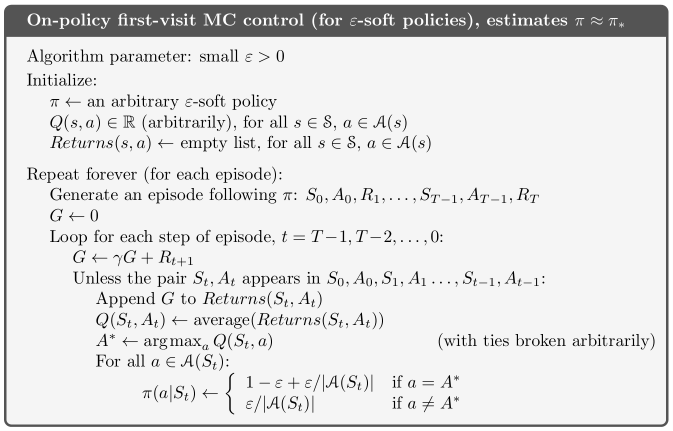

Exploring Starts requires the environment to begin from many different state-action pairs. That assumption is often unrealistic. Some environments always reset to the same initial state.

The solution is to keep the normal starting-state mechanism and place exploration **inside the policy**.

Let

$$
a^*=\arg\max_a Q(s,a).
$$

For $m=|\mathcal A(s)|$ available actions, an $\epsilon$-greedy policy is

$$
\pi(a\mid s)
=
\begin{cases}
1-\epsilon+\dfrac{\epsilon}{m},
& a=a^*,\\[8pt]
\dfrac{\epsilon}{m},
& a\neq a^*.
\end{cases}
$$

Thus the policy usually chooses a greedy action but continues to explore.

For example, with four available actions and

$$
\epsilon=0.1,
$$

the greedy action receives probability

$$
1-0.1+\frac{0.1}{4}
=
\boxed{0.925},
$$

while each non-greedy action receives

$$
\frac{0.1}{4}
=
\boxed{0.025}.
$$

## On-Policy First-Visit MC Control with $\epsilon$-Greedy Exploration

```text
Input:
    discount factor γ
    exploration rate ε
    number of episodes n_ep

Initialize:
    Q(s, a) arbitrarily
    Returns(s, a) as empty lists

Construct an ε-greedy policy π from Q

For episode = 1 to n_ep:

    1. Generate a complete episode using π
       S0, A0, R1, ..., S_{T-1}, A_{T-1}, R_T

    2. Initialize
       G = 0

    3. Process the episode backward
       For t = T - 1, T - 2, ..., 0:

           G = γG + R_{t+1}

           If (S_t, A_t) does not appear earlier in the episode:

               Append G to Returns(S_t, A_t)

               Q(S_t, A_t) = average(Returns(S_t, A_t))

               A* = argmax_a Q(S_t, a)

               For every a in A(S_t):

                   π(a | S_t) =  1 - ε + ε / |A(S_t)|
                       if a = A*

                   π(a | S_t) =  ε / |A(S_t)|
                       otherwise

Return Q and π
```

This is **on-policy** control because the same $\epsilon$-greedy policy is used both to generate experience and to improve the action-value estimates.

## Fully Worked $\epsilon$-Greedy MC Control Example

To make the $\epsilon$-greedy algorithm as explicit as the First-Visit, Every-Visit, and MC-ES examples, use a small deterministic grid with a **fixed start state**.

|  |  |  |
|---|---|---|
| $s_0$ Target | $s_1$ | $s_2$ |
| $s_3$ | $s_4$ | $s_5$ Start |

The agent always starts at

$$
\boxed{s_5}.
$$

Therefore there are **no exploring starts**.

The valid actions are movements that stay inside the grid. The reward is

$$
R_{t+1}
=
\begin{cases}
+10, & \text{if the next state is }s_0,\\
-1, & \text{otherwise}.
\end{cases}
$$

Use

$$
\gamma=0.9,
\qquad
\epsilon=0.2.
$$

Initially,

$$
Q(s,a)=0
$$

for every valid state-action pair.

When several actions are tied for the maximum $Q$-value, use the deterministic tie-breaking order

$$
L \;>\; U \;>\; R \;>\; D
$$

among the actions that are valid in that state.

For $m=|\mathcal A(s)|$ valid actions,

$$
\pi(a\mid s)
=
\begin{cases}
1-\epsilon+\dfrac{\epsilon}{m}, & a=a^*,\\[8pt]
\dfrac{\epsilon}{m}, & a\neq a^*,
\end{cases}
$$

where

$$
a^*=\arg\max_a Q(s,a).
$$

### Initial $\epsilon$-Greedy Probabilities

At $s_5$, the valid actions are

$$
\mathcal A(s_5)=\{L,U\}.
$$

Since both action values initially equal zero, the tie-breaking rule selects $L$ as the greedy action.

There are

$$
m=2
$$

valid actions, so

$$
P(L\mid s_5)
=
1-0.2+\frac{0.2}{2}
=
\boxed{0.9},
$$

and

$$
P(U\mid s_5)
=
\frac{0.2}{2}
=
\boxed{0.1}.
$$

At a state with three valid actions, the greedy-action probability is

$$
1-0.2+\frac{0.2}{3}
=
\boxed{0.8667},
$$

while each non-greedy action has probability

$$
\frac{0.2}{3}
=
\boxed{0.0667}.
$$

## $\epsilon$-Greedy Episode $E_1$

Every episode begins from the fixed start state

$$
S_0=s_5.
$$

Suppose the sampled actions produce

$$
\boxed{
(s_5,L)
\rightarrow
(s_4,L)
\rightarrow
(s_3,U)
\rightarrow
s_0
}.
$$

### Action-selection probabilities

At $s_5$,

$$
P(L\mid s_5)=0.9.
$$

The greedy action $L$ is selected.

At $s_4$, the valid actions are

$$
\mathcal A(s_4)=\{L,U,R\}.
$$

All $Q$-values are initially zero. The tie-breaking rule chooses $L$ as greedy:

$$
P(L\mid s_4)=0.8667,
$$

$$
P(U\mid s_4)=P(R\mid s_4)=0.0667.
$$

Action $L$ is selected.

At $s_3$,

$$
\mathcal A(s_3)=\{U,R\}.
$$

The tie-breaking rule selects $U$ as greedy:

$$
P(U\mid s_3)=0.9,
\qquad
P(R\mid s_3)=0.1.
$$

Action $U$ is selected and enters the target.

### Episode $E_1$ with rewards

The complete state-action-reward sequence is

$$
\boxed{
(s_5,L,-1)
\rightarrow
(s_4,L,-1)
\rightarrow
(s_3,U,+10)
\rightarrow
s_0
}.
$$

The algorithm waits until the episode is complete and then processes it backward.

Initialize

$$
G=0.
$$

### Step 1: $(s_3,U)$

The final transition enters the target:

$$
R_{t+1}=+10.
$$

Therefore,

$$
G
=
\gamma G+R_{t+1}
$$

$$
=
(0.9)(0)+10
$$

$$
=
\boxed{10}.
$$

This is the first occurrence of $(s_3,U)$, so

$$
\text{Returns}(s_3,U)=[10].
$$

Hence,

$$
Q(s_3,U)
=
\frac{10}{1}
=
\boxed{10}.
$$

### Step 2: $(s_4,L)$

The previous value of $G$ is $10$, and the reward after $(s_4,L)$ is $-1$:

$$
G
=
(0.9)(10)-1
$$

$$
=
9-1
$$

$$
=
\boxed{8}.
$$

Therefore,

$$
\text{Returns}(s_4,L)=[8],
$$

and

$$
Q(s_4,L)
=
\frac{8}{1}
=
\boxed{8}.
$$

### Step 3: $(s_5,L)$

Now

$$
G
=
(0.9)(8)-1
$$

$$
=
7.2-1
$$

$$
=
\boxed{6.2}.
$$

Thus,

$$
\text{Returns}(s_5,L)=[6.2],
$$

and

$$
Q(s_5,L)
=
\frac{6.2}{1}
=
\boxed{6.2}.
$$

### Policy update after $E_1$

At $s_5$,

$$
Q(s_5,L)=6.2,
\qquad
Q(s_5,U)=0.
$$

Therefore,

$$
a^*=\arg\max_aQ(s_5,a)=L.
$$

The updated $\epsilon$-greedy probabilities are still

$$
\boxed{P(L\mid s_5)=0.9},
$$

$$
\boxed{P(U\mid s_5)=0.1}.
$$

At $s_4$,

$$
Q(s_4,L)=8
$$

is larger than the still-unvisited actions:

$$
Q(s_4,U)=Q(s_4,R)=0.
$$

Therefore,

$$
\boxed{P(L\mid s_4)=0.8667},
$$

$$
\boxed{P(U\mid s_4)=P(R\mid s_4)=0.0667}.
$$

At $s_3$,

$$
Q(s_3,U)=10>Q(s_3,R)=0,
$$

so

$$
\boxed{P(U\mid s_3)=0.9},
\qquad
\boxed{P(R\mid s_3)=0.1}.
$$

## $\epsilon$-Greedy Episode $E_2$

The second episode again begins from

$$
s_5.
$$

At $s_5$,

$$
P(L\mid s_5)=0.9,
\qquad
P(U\mid s_5)=0.1.
$$

Suppose the exploratory action $U$ is selected.

The transition is

$$
s_5\xrightarrow{U,-1}s_2.
$$

At $s_2$, the valid actions are

$$
\mathcal A(s_2)=\{L,D\}.
$$

Both currently have

$$
Q(s_2,L)=Q(s_2,D)=0.
$$

The tie-breaking rule makes $L$ greedy:

$$
P(L\mid s_2)=0.9,
\qquad
P(D\mid s_2)=0.1.
$$

Suppose exploration selects $D$, returning to $s_5$.

From there, the agent chooses the high-probability greedy path

$$
s_5\xrightarrow{L}s_4\xrightarrow{L}s_3\xrightarrow{U}s_0.
$$

Thus the complete episode is

$$
\boxed{
(s_5,U)
\rightarrow
(s_2,D)
\rightarrow
(s_5,L)
\rightarrow
(s_4,L)
\rightarrow
(s_3,U)
\rightarrow
s_0
}.
$$

### Episode $E_2$ with rewards

$$
\boxed{
(s_5,U,-1)
\rightarrow
(s_2,D,-1)
\rightarrow
(s_5,L,-1)
\rightarrow
(s_4,L,-1)
\rightarrow
(s_3,U,+10)
\rightarrow
s_0
}.
$$

Initialize

$$
G=0.
$$

### Step 1: $(s_3,U)$

$$
G=(0.9)(0)+10=\boxed{10}.
$$

The return list becomes

$$
\text{Returns}(s_3,U)=[10,10].
$$

Therefore,

$$
Q(s_3,U)
=
\frac{10+10}{2}
=
\boxed{10}.
$$

### Step 2: $(s_4,L)$

$$
G=(0.9)(10)-1=\boxed{8}.
$$

Now

$$
\text{Returns}(s_4,L)=[8,8],
$$

so

$$
Q(s_4,L)
=
\frac{8+8}{2}
=
\boxed{8}.
$$

### Step 3: second visit to state $s_5$, pair $(s_5,L)$

Although $s_5$ appeared earlier in the episode, the earlier action was $U$.

The current pair

$$
(s_5,L)
$$

is different from

$$
(s_5,U).
$$

Therefore, both pairs can be First-Visit state-action updates.

For $(s_5,L)$,

$$
G=(0.9)(8)-1
$$

$$
=\boxed{6.2}.
$$

The return list becomes

$$
\text{Returns}(s_5,L)=[6.2,6.2].
$$

Thus,

$$
Q(s_5,L)
=
\frac{6.2+6.2}{2}
=
\boxed{6.2}.
$$

### Step 4: $(s_2,D)$

$$
G
=
(0.9)(6.2)-1
$$

$$
=
5.58-1
$$

$$
=
\boxed{4.58}.
$$

Therefore,

$$
\text{Returns}(s_2,D)=[4.58],
$$

and

$$
Q(s_2,D)=\boxed{4.58}.
$$

### Step 5: first state-action pair $(s_5,U)$

Continue backward:

$$
G
=
(0.9)(4.58)-1
$$

$$
=
4.122-1
$$

$$
=
\boxed{3.122}.
$$

Therefore,

$$
\text{Returns}(s_5,U)=[3.122],
$$

and

$$
Q(s_5,U)
=
\boxed{3.122}.
$$

### Policy update after $E_2$

At $s_5$,

$$
Q(s_5,L)=6.2,
$$

$$
Q(s_5,U)=3.122.
$$

Therefore,

$$
\boxed{a^*=L}.
$$

With two valid actions,

$$
\boxed{P(L\mid s_5)=0.9},
$$

$$
\boxed{P(U\mid s_5)=0.1}.
$$

At $s_2$,

$$
Q(s_2,D)=4.58,
$$

$$
Q(s_2,L)=0.
$$

Therefore the greedy action has changed from the tie-broken $L$ to

$$
\boxed{D}.
$$

Hence,

$$
\boxed{P(D\mid s_2)=0.9},
$$

$$
\boxed{P(L\mid s_2)=0.1}.
$$

## $\epsilon$-Greedy Episode $E_3$

Again,

$$
S_0=s_5.
$$

Suppose exploration selects

$$
U
$$

at $s_5$:

$$
P(U\mid s_5)=0.1.
$$

The agent reaches $s_2$.

After $E_2$,

$$
Q(s_2,D)=4.58,
\qquad
Q(s_2,L)=0,
$$

so

$$
P(D\mid s_2)=0.9,
\qquad
P(L\mid s_2)=0.1.
$$

Suppose exploration now selects $L$.

At $s_1$, the valid actions are

$$
\mathcal A(s_1)=\{L,R,D\}.
$$

All are still unvisited and tied at zero, so the tie-breaking rule makes $L$ greedy:

$$
P(L\mid s_1)
=
1-0.2+\frac{0.2}{3}
=
\boxed{0.8667}.
$$

Suppose $L$ is selected, entering the target.

The full episode is

$$
\boxed{
(s_5,U)
\rightarrow
(s_2,L)
\rightarrow
(s_1,L)
\rightarrow
s_0
}.
$$

### Episode $E_3$ with rewards

$$
\boxed{
(s_5,U,-1)
\rightarrow
(s_2,L,-1)
\rightarrow
(s_1,L,+10)
\rightarrow
s_0
}.
$$

Initialize

$$
G=0.
$$

### Step 1: $(s_1,L)$

$$
G=(0.9)(0)+10
=
\boxed{10}.
$$

Thus,

$$
\text{Returns}(s_1,L)=[10],
$$

and

$$
Q(s_1,L)=\boxed{10}.
$$

### Step 2: $(s_2,L)$

$$
G=(0.9)(10)-1
$$

$$
=9-1
$$

$$
=\boxed{8}.
$$

Therefore,

$$
\text{Returns}(s_2,L)=[8],
$$

and

$$
Q(s_2,L)=\boxed{8}.
$$

### Step 3: $(s_5,U)$

$$
G=(0.9)(8)-1
$$

$$
=7.2-1
$$

$$
=\boxed{6.2}.
$$

The return list for $(s_5,U)$ was

$$
[3.122].
$$

After $E_3$,

$$
\text{Returns}(s_5,U)
=
[3.122,6.2].
$$

Therefore,

$$
Q(s_5,U)
=
\frac{3.122+6.2}{2}
$$

$$
=
\frac{9.322}{2}
$$

$$
=
\boxed{4.661}.
$$

At $s_5$,

$$
Q(s_5,L)=6.2>Q(s_5,U)=4.661.
$$

So $L$ remains greedy:

$$
\boxed{P(L\mid s_5)=0.9},
\qquad
\boxed{P(U\mid s_5)=0.1}.
$$

### Policy change at $s_2$ after $E_3$

Before $E_3$,

$$
Q(s_2,D)=4.58,
\qquad
Q(s_2,L)=0,
$$

so $D$ was greedy.

After $E_3$,

$$
Q(s_2,D)=4.58,
$$

$$
Q(s_2,L)=8.
$$

Now

$$
8>4.58,
$$

so the greedy action becomes

$$
\boxed{L}.
$$

Therefore, the updated $\epsilon$-greedy probabilities are

$$
\boxed{P(L\mid s_2)=0.9},
$$

$$
\boxed{P(D\mid s_2)=0.1}.
$$

This is the complete MC control cycle:

$$
\boxed{
Q
\rightarrow
\epsilon\text{-greedy action probabilities}
\rightarrow
\text{episode}
\rightarrow
G
\rightarrow
\text{Returns}
\rightarrow
Q
\rightarrow
\text{updated policy}
}.
$$

## Final values after the three worked $\epsilon$-greedy episodes

The observed return lists are

$$
\text{Returns}(s_5,L)=[6.2,6.2],
$$

$$
\text{Returns}(s_5,U)=[3.122,6.2],
$$

$$
\text{Returns}(s_4,L)=[8,8],
$$

$$
\text{Returns}(s_3,U)=[10,10],
$$

$$
\text{Returns}(s_2,D)=[4.58],
$$

$$
\text{Returns}(s_2,L)=[8],
$$

$$
\text{Returns}(s_1,L)=[10].
$$

Therefore,

$$
Q(s_5,L)=6.2,
$$

$$
Q(s_5,U)=4.661,
$$

$$
Q(s_4,L)=8,
$$

$$
Q(s_3,U)=10,
$$

$$
Q(s_2,D)=4.58,
$$

$$
Q(s_2,L)=8,
$$

$$
Q(s_1,L)=10.
$$

The important policy changes can now be seen directly from the $Q$-values rather than simply stated.

In [ ]:
# Python verification of the three hand-worked epsilon-greedy episodes.

epsilon = 0.2
gamma = 0.9

episodes_eps_manual = {
    "E1": [("s5", "L", -1), ("s4", "L", -1), ("s3", "U", 10)],
    "E2": [("s5", "U", -1), ("s2", "D", -1), ("s5", "L", -1), ("s4", "L", -1), ("s3", "U", 10)],
    "E3": [("s5", "U", -1), ("s2", "L", -1), ("s1", "L", 10)],
}

def first_visit_action_returns(episodes, gamma=0.9):
    returns = defaultdict(list)
    traces = {}

    for name, episode in episodes.items():
        pairs = [(state, action) for state, action, _ in episode]
        G = 0.0
        rows = []

        for t in range(len(episode) - 1, -1, -1):
            state, action, reward = episode[t]
            G = gamma * G + reward
            pair = (state, action)
            first_visit = pair not in pairs[:t]

            if first_visit:
                returns[pair].append(G)

            rows.append((t, state, action, reward, G, first_visit))

        traces[name] = list(reversed(rows))

    Q = {pair: float(np.mean(values)) for pair, values in returns.items()}
    return returns, Q, traces

eps_returns_manual, eps_q_manual, eps_traces_manual = first_visit_action_returns(
    episodes_eps_manual, gamma=gamma
)

for name in ["E1", "E2", "E3"]:
    print(f"\n{name}")
    display(pd.DataFrame(
        eps_traces_manual[name],
        columns=["t", "State", "Action", "Reward", "G_t", "First visit of (s,a)?"]
    ))

display(pd.DataFrame(
    [(s, a, values, eps_q_manual[(s, a)])
     for (s, a), values in sorted(eps_returns_manual.items())],
    columns=["State", "Action", "Returns List", "Q(s,a)"]
))


E1


,t,State,Action,Reward,G_t,"First visit of (s,a)?"
0,0,s5,L,-1,6.2,True
1,1,s4,L,-1,8.0,True
2,2,s3,U,10,10.0,True



E2


,t,State,Action,Reward,G_t,"First visit of (s,a)?"
0,0,s5,U,-1,3.122,True
1,1,s2,D,-1,4.580,True
2,2,s5,L,-1,6.200,True
3,3,s4,L,-1,8.000,True
4,4,s3,U,10,10.000,True



E3


,t,State,Action,Reward,G_t,"First visit of (s,a)?"
0,0,s5,U,-1,6.2,True
1,1,s2,L,-1,8.0,True
2,2,s1,L,10,10.0,True


,State,Action,Returns List,"Q(s,a)"
0,s1,L,[10.0],10.000
1,s2,D,[4.58],4.580
2,s2,L,[8.0],8.000
3,s3,U,"[10.0, 10.0]",10.000
4,s4,L,"[8.0, 8.0]",8.000
5,s5,L,"[6.2, 6.2]",6.200
6,s5,U,"[3.122, 6.2]",4.661


In [ ]:
# Helper functions used by the full fixed-start epsilon-greedy training experiment.

import random

def step_grid(state, action):
    r, c = positions[state]
    dr, dc = action_delta[action]
    next_state = grid[r + dr][c + dc]
    reward = 100 if next_state == "s0" else -1
    done = next_state == "s0"
    return next_state, reward, done

def epsilon_greedy_action(state, Q, epsilon, rng):
    actions = valid_actions(state)

    if rng.random() < epsilon:
        return rng.choice(actions)

    values = [Q[(state, action)] for action in actions]
    best_value = max(values)
    best_actions = [
        action
        for action, value in zip(actions, values)
        if value == best_value
    ]
    return rng.choice(best_actions)

## Train $\epsilon$-Greedy MC Control on the Grid

The following implementation uses a sample-average update

$$
Q(s,a)
\leftarrow
Q(s,a)
+
\frac{1}{N(s,a)}
\left[
G-Q(s,a)
\right].
$$

This is mathematically equivalent to storing every observed return and averaging the complete list, but it uses less memory.

No exploring starts are used: every episode begins at $s_{20}$.

In [ ]:
def mc_epsilon_greedy_control(
    num_episodes=5000,
    gamma=0.9,
    epsilon=0.1,
    start_state="s20",
    max_steps=100,
    seed=2
):
    rng = random.Random(seed)
    Q = defaultdict(float)
    N = defaultdict(int)
    episode_returns = []
    episode_lengths = []

    for _ in range(num_episodes):
        state = start_state
        episode = []

        for _ in range(max_steps):
            action = epsilon_greedy_action(state, Q, epsilon, rng)
            next_state, reward, done = step_grid(state, action)
            episode.append((state, action, reward))
            state = next_state

            if done:
                break

        episode_returns.append(sum(reward for _, _, reward in episode))
        episode_lengths.append(len(episode))

        G = 0.0
        G_values = [0.0] * len(episode)

        for t in range(len(episode) - 1, -1, -1):
            state, action, reward = episode[t]
            G = gamma * G + reward
            G_values[t] = G

        seen = set()

        for t, (state, action, reward) in enumerate(episode):
            pair = (state, action)

            if pair not in seen:
                seen.add(pair)
                N[pair] += 1
                Q[pair] += (G_values[t] - Q[pair]) / N[pair]

    return Q, N, episode_returns, episode_lengths

Q_mc, N_mc, mc_returns, mc_lengths = mc_epsilon_greedy_control()
print("Training complete.")
print("Mean episode length over the last 500 episodes:", round(np.mean(mc_lengths[-500:]), 3))

Training complete.
Mean episode length over the last 500 episodes: 8.956


In [ ]:
def greedy_policy_from_q(Q):
    policy = {}

    for state in positions:
        if state == "s0":
            continue

        actions = valid_actions(state)
        values = [Q[(state, action)] for action in actions]
        best_value = max(values)
        best_actions = [action for action, value in zip(actions, values) if value == best_value]
        policy[state] = sorted(best_actions)[0]

    return policy

def follow_greedy_policy(Q, start_state="s20", max_steps=50):
    state = start_state
    path = [state]
    actions_taken = []

    for _ in range(max_steps):
        actions = valid_actions(state)
        values = [Q[(state, action)] for action in actions]
        best_value = max(values)
        best_action = sorted([action for action, value in zip(actions, values) if value == best_value])[0]

        actions_taken.append(best_action)
        state, reward, done = step_grid(state, best_action)
        path.append(state)

        if done:
            break

    return path, actions_taken

learned_policy = greedy_policy_from_q(Q_mc)
greedy_path, greedy_actions = follow_greedy_policy(Q_mc)

print("Greedy path after training:")
print(" -> ".join(greedy_path))
print("\nActions:")
print(" -> ".join(greedy_actions))

Greedy path after training:
s20 -> s19 -> s18 -> s17 -> s16 -> s15 -> s11 -> s6 -> s0

Actions:
L -> L -> L -> L -> L -> U -> U -> U


In [ ]:
policy_grid = []
for row in grid:
    policy_row = []
    for state in row:
        if state is None:
            policy_row.append("BLOCK")
        elif state == "s0":
            policy_row.append("T")
        else:
            policy_row.append(learned_policy[state])
    policy_grid.append(policy_row)

pd.DataFrame(policy_grid)

,0,1,2,3,4,5
0,T,L,L,R,R,D
1,U,L,L,L,BLOCK,D
2,U,BLOCK,U,BLOCK,D,L
3,U,L,L,L,L,L


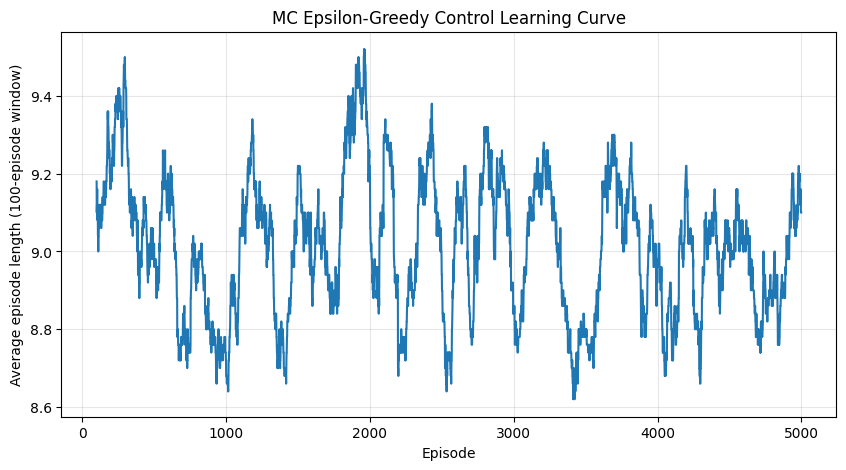

In [ ]:
window = 100
moving_length = pd.Series(mc_lengths).rolling(window).mean()

plt.figure(figsize=(10, 5))
plt.plot(moving_length)
plt.xlabel("Episode")
plt.ylabel(f"Average episode length ({window}-episode window)")
plt.title("MC Epsilon-Greedy Control Learning Curve")
plt.grid(alpha=0.3)
plt.show()

# 7. Monte Carlo Limitation and the Transition to TD Learning

Monte Carlo methods update values from the complete return

$$
G_t.
$$

Therefore, the algorithm normally waits until the episode has ended before the return is available.

This is one of the main differences between Monte Carlo and Temporal-Difference learning.

Monte Carlo target:

$$
\boxed{\text{Target}_{MC}=G_t}
$$

TD(0) target:

$$
\boxed{
\text{Target}_{TD}
=
R_{t+1}
+
\gamma V(S_{t+1})
}
$$

Monte Carlo uses the complete sampled return and does **not** bootstrap.

Temporal-Difference learning can update after each transition and **does bootstrap**.

This gives the natural progression

$$
\boxed{
\text{Monte Carlo}
\longrightarrow
\text{Temporal-Difference Learning}
}.
$$

# Worked-Calculation Coverage

Each Monte Carlo algorithm in this notebook now follows the same calculation pattern:

1. state the algorithm,
2. print the complete episode,
3. show the reward attached to every transition,
4. initialize $G=0$,
5. process the episode backward using

$$
G\leftarrow \gamma G+R_{t+1},
$$

6. show the First-Visit or Every-Visit test when required,
7. update the return list or return sum,
8. update $N(s)$, $V(s)$, or $Q(s,a)$,
9. update the policy when the algorithm is a control method,
10. verify the hand calculation with Python.

This pattern is used for First-Visit MC Prediction, Every-Visit MC Prediction, MC Exploring Starts, and $\epsilon$-Greedy MC Control.

# Summary

The main ideas in this notebook are:

- **First-Visit MC Prediction:** average returns following the first occurrence of each state in an episode.
- **Every-Visit MC Prediction:** average returns following every occurrence of each state.
- **MC Exploring Starts:** estimate $Q(s,a)$ and improve a greedy policy while forcing coverage through random starting state-action pairs.
- **$\epsilon$-Greedy MC Control:** remove the Exploring Starts assumption and explore through the policy itself.
- **Monte Carlo limitation:** a complete return is needed before the usual MC update can be made.

The common return recursion throughout the notebook is

$$
\boxed{
G\leftarrow \gamma G+R_{t+1}
}.
$$